<a href="https://colab.research.google.com/github/KANGWEII/hands_on_ml/blob/feature-chapter_3/Chapter03/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Classification

## MNIST

In [ ]:
# fetch_openml throw error, use keras to import dataset instead

from tensorflow import keras

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


- 70000 images and each image has 784 features
  - 60000 train images
  - 10000 test images
  - 28x28 pixels (784 features)

In [ ]:
X_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [ ]:
X_train.shape

(60000, 784)

In [ ]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [ ]:
y_train.shape

(60000,)

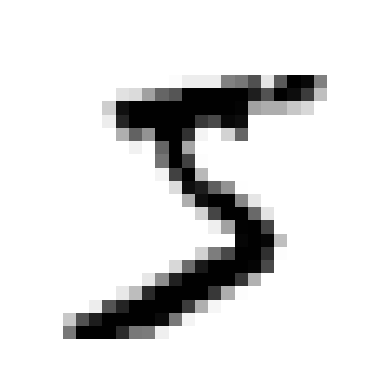

In [ ]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
  image = image_data.reshape(28, 28)
  plt.imshow(image, cmap="binary")
  plt.axis("off")

some_digit = X_train[0]
plot_digit(some_digit)
plt.show()

In [ ]:
# Check the label of plotted digit
y_train[0]

np.uint8(5)

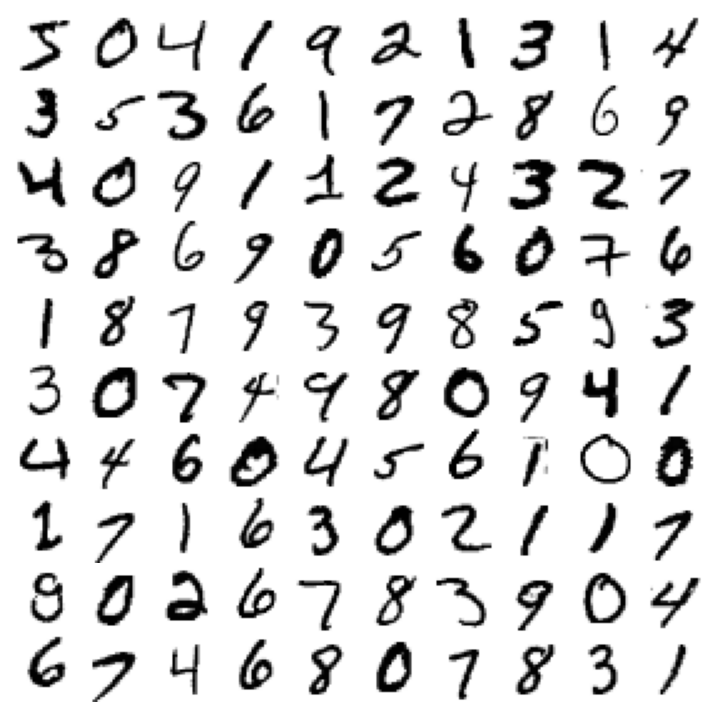

In [ ]:
# Plot first 100 digits in the dataset
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X_train[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

## Training a Binary Classifier

- Start by identifying one digit (*binary classifier*)
  - distinguish between 5 and non-5
- Select classifier
  - SGD (Stochastic Gradient Decent)
  - Capable to handle large datasets
  - SGD is well suited for online learning

In [ ]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

# Predict the first digit plotted above
sgd_clf.predict([some_digit])

array([ True])

## Performance Measures

### Measuring Accuracy Using Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy", n_jobs=-1)

array([0.95035, 0.96035, 0.9604 ])

Using dummy classifier to test or compare the performance of more complex clasifier
- `DummyClassifier(strategy=)`
- `strategy=most_frequent` by default, always predicts the most common class in the training data, non-5 in this case

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)

# Print False: no 5s detected
print(any(dummy_clf.predict(X_train)))

# Model's accuracy
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy", n_jobs=-1)

False


array([0.90965, 0.90965, 0.90965])

Over 90% accuracy?
- Only about 10% of the images are 5s
- if always guess that an image is not a 5, it will be right about 90% of the time
- *accuracy* is not the preffered performance measurement for clasifier especially when dealing with skewed datasets
- Skewed dataset is one where the classes are unevenly distributed, meaning one class has much more data than the others (eg. 5 and non-5)
- Confusion Matrix (CM) is a better way to evaluate the performance of a classifier

### Confusion Matrices

- Count the number of times class A are classified as class B
- eg. to know the number of times the classifier confused images of 5s with 3s, look at row #5, colmun #3 of the matrix


cross_val_predict()
- like cross_val_score() but instead of returning evaluation scores, returns predictions on each test fold

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, n_jobs=-1)
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

Confusion Matrix
- row: actual class
- column: predicted class
- First row (non-5): First column: 53892 correctly classified (true negatives, type I errors)
- First row (non-5): Second column: 687 incorrectly classified (false positives)
- Second row (5): First column: 1891 incorrectly classified (false negatives, type II errors)
- Second row (5): Second column: 3530 correctly classified (true positives)

A more conceise metric:
- Precesion - measures how accurate the positive predictions are
- Recall - measures how complete the positive predictions are

### Precision and Recall

In [ ]:
from sklearn.metrics import precision_score, recall_score

# Correct only 83.7%
precision_score(y_train_5, y_train_pred)  # 3530 / (687+3530)

0.8370879772350012

In [ ]:
# Only detects 65.1% of the 5s
recall_score(y_train_5, y_train_pred) # 3530 / (1891+3530)

0.6511713705958311

F1 score - combining both precision and recall into a single metric
- harmonic mean of precision and recall
- gives much more weight to low values
- F1 score is high when both recall and precision are high

In [ ]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7325171197343847

### The Precision/Recall Trade-off

- Increasing precision reduces recall, and vice versa
- Most classifiers produce a probability score
  - An observation is classified as positive if the score ≥ some threshold
  - **Lowering the threshold** → more positives predicted
    - *Recall* ↑ (catch more true positives)
    - *Precision* ↓ (more false positives too)
  - **Raising the threshold** → fewer positives predicted
    - *Precision* ↑ (fewer false alarms)
    - *Recall* ↓ (miss more actual positives)
  - Examples
    - Medical diagnosis: prioritize recall (catch all actual cases, even if some false alarms)
    - Email spam detection: prioritize precision (prevent misclassify important emails)

In [ ]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [ ]:
# Use any threshold to make predictions from the scores retrieve from decision_fuction()

threshold = 0
y_some_digit_pred = (y_scores > threshold)

In [ ]:
# Raising threhold decreases recall

threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

How to decide which threshold to use?
1. Use `cross_val_predict()` function with argument `method="decision_function"` to get the decision scores
2. Use `precision_recall_curve` function to compute precision and recall for all possible thresholds
3. Use Matplotlib to plot precison and recall as functions of the threshold value
4. Plot another graph with precision against recall
5. Use argmax() method to get the dersired threshold value based on the precision and recall value you want

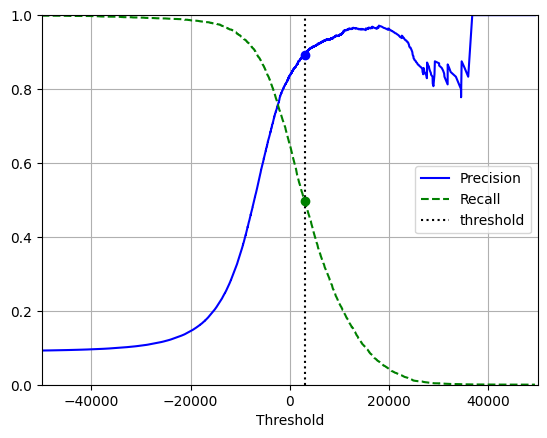

In [ ]:
# Step 1
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

# Step 2
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

# Step 3
plt.plot(thresholds, precisions[:-1], "b-", label="Precision")
plt.plot(thresholds, recalls[:-1], "g--", label="Recall")
plt.vlines(threshold, 0, 1, "k", "dotted", label="threshold") # Show threshold of 3000 selected above
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.show()



Why is precision curve bumpier than the recall curve?

- Recall
  $$Recall = \frac{TP}{TP + FN}$$
  - As threshold ↑
    - TP can only decrease or stay the same (because lesser score will fall in the threshold)
    - FN can only increase or stay the same (since some TPs might turn into FNs)
  - So recall will monotonically decrease or stay flat

- Precision
  $$Precision = \frac{TP}{TP + FP}$$
  - As threshold ↑
    - TP and FP can only decrease or stay the same
    - If TP decreases first, numerator drops more: *precision* ↓
    - If FP decreases first, denominator shrinks faster: *precision* ↑
  - Relative drop between TP and FP changes step by step, precision fluctuates, resulting in bumpier curve

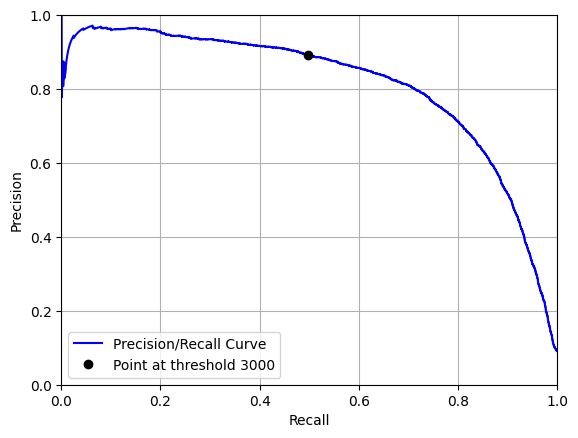

In [ ]:
# Step 4
plt.plot(recalls, precisions, "b-", label="Precision/Recall Curve")
plt.plot([recalls[idx]], [precisions[idx]], "ko", label="Point at threshold 3000")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [ ]:
# Step 5

idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

In [ ]:
# Make predictions using the desired threshold

y_train_pred_90 = (y_scores >= threshold_for_90_precision)

precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [ ]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

### The ROC Curve

- Receiver Operating Characteristic (ROC)
- Plot *true positive rate* (TPR) against the *false positive rate* (fall-out)
- TPR: also known as recall
- fall-out: aka false positive rate (FPR), ratio of negative instances that are incorrectly classified as positive. Equal to (1 - turn negative rate)
- (FPR) = FP / (FP + TN)
- true negative rate (TNR): ratio of negative instances that are correctly classified as negative, also called *specificity*
- ROC is the plot of sensitivity versus (1-specificity)

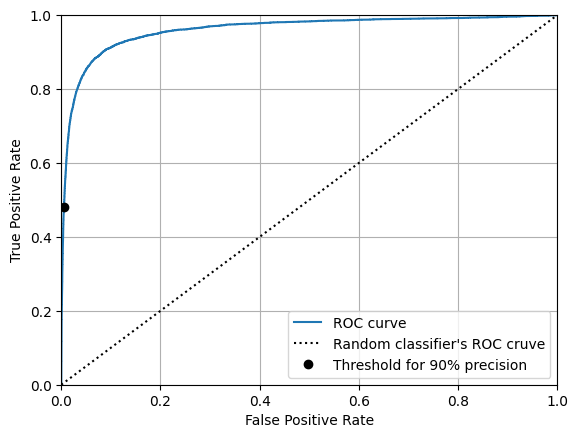

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()

tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC cruve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.legend(loc="lower right")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.axis ([0, 1, 0, 1])
plt.grid()

- The dotted line represents the ROC curve of a purely random classifier
- A good classifier stays as far away from that line as possible, towards the top-left corner
- One way to compare classifier is area under the curve (AUC)
- Perfect classifier will have a ROC AUC equal to 1, purely random classifier ROC AUC is 0.5

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

np.float64(0.9604938554008616)

When to use ROC curve or precision/recall curve?
- Use PR curve whenever the positive class (5 in this case) is rare or when false positives are more important than false negatives
- Otherwise, use ROC
- In this case, PR curve makes it clear that the  classifier has room for improvement, where the curve could be closer to the top-right corner

Use `RandomForestClassifier` and compare to SGD above
- RandomForestClassifier does not have a `decision_function()` method (Cover in Chapter 7)
- Use `predict_proba()` method to get probabilities for each instance

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba", n_jobs=-1)
y_probas_forest[:3]

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04]])

In [ ]:
y_scores_forest = y_probas_forest[:, 1]
fpr_forest, tpr_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

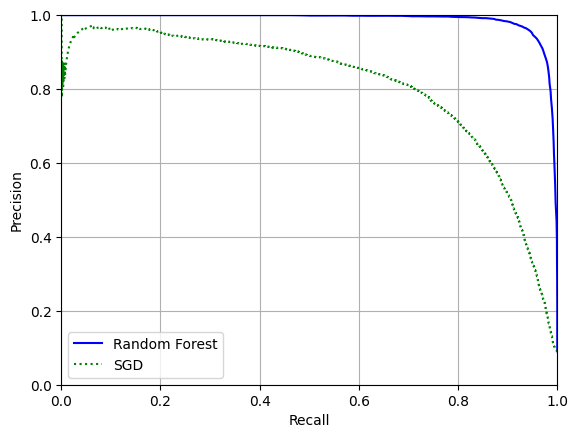

In [ ]:
plt.plot(tpr_forest, fpr_forest, "b-", label="Random Forest")
plt.plot(recalls, precisions, "g:", label="SGD")
plt.legend(loc="lower left")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.show()

In [ ]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5
f1_score(y_train_5, y_train_pred_forest)

0.9274509803921569

- RandomForestClassifier's PR curve performs better than SGDClassifier's, it is closer to the top-right corner
- F1 score is also significantly better

In [ ]:
roc_auc_score(y_train_5, y_scores_forest)

np.float64(0.9983436731328145)

In [ ]:
precision_score(y_train_5, y_train_pred_forest)

0.9897468089558485

In [ ]:
recall_score(y_train_5, y_train_pred_forest)

0.8725327430363402

## Multiclass Classification

One-versus-the-rest (OvR) or one-versus-all (OvA)
- Train 10 binary classifiers, one for each digit

One-versus-one (OvO)
- Train a binary classifier for every pair of digits: 0s and 1s, 0s and 2s, 0s and 3s, and so on
- If there are N classes, there are (N X (N - 1) / 2) classifiers
- 45 classifiers for MNIST dataset

- Some algorithms scale poorly with the size of training set, hence OvO is preferred to train many classifiers on small training sets
- However, most binary classification algorithms prefer OvR

In [ ]:
# Scikit-Learn detects the use of binary classification algorithm on multiclass classification task, and it will automatically run OvR or OvO depending on the algorithm
# This uses OvO strategy

from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])
svm_clf.predict([some_digit])

array([5], dtype=uint8)

In [ ]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

In [ ]:
# Highest score is 9.3

class_id = some_digit_scores.argmax()
svm_clf.classes_[class_id]

np.uint8(5)

In [ ]:
# For decision_function() to return all 45 scores
# Set the decision_function_shape hyperparameter to "ovo". The default value is "ovr"
# But SVC always use OvO for training

svm_clf.decision_function_shape = "ovo"
some_digit_scores_ovo = svm_clf.decision_function([some_digit])
some_digit_scores_ovo.round(2)

array([[ 0.11, -0.21, -0.97,  0.51, -1.01,  0.19,  0.09, -0.31, -0.04,
        -0.45, -1.28,  0.25, -1.01, -0.13, -0.32, -0.9 , -0.36, -0.93,
         0.79, -1.  ,  0.45,  0.24, -0.24,  0.25,  1.54, -0.77,  1.11,
         1.13,  1.04,  1.2 , -1.42, -0.53, -0.45, -0.99, -0.95,  1.21,
         1.  ,  1.  ,  1.08, -0.02, -0.67, -0.14, -0.3 , -0.13,  0.25]])

- **Pairs starting with 0** (9 pairs): (0, 1) to (0, 9)
- **Pairs starting with 1** (8 pairs): (1, 2) to (1, 9)
- **Pairs starting with 2** (7 pairs): (2, 3) to (2, 9)
- **Pairs starting with 3** (6 pairs): (3, 4) to (3, 9)
- **Pairs starting with 4** (5 pairs): (4, 5) to (4, 9)
- **Pairs starting with 5** (4 pairs): (5, 6) to (5, 9)
- **Pairs starting with 6** (3 pairs): (6, 7) to (6, 9)
- **Pairs starting with 7** (2 pairs): (7, 8) to (7, 9)
- **Pairs starting with 8** (1 pair): (8, 9)

Positive score means the first digit in the pair is favored, and a negative score means the second digit is favored. The final prediction is the classifier with the most votes.

- To force Scikit-Learn to use OvR or OvO, use `OneVsOneClassifier` or `OneVsRestClassifier`

In [ ]:
from sklearn.multiclass import OneVsRestClassifier

ovr_cld = OneVsRestClassifier(SVC(random_state=42))
ovr_cld.fit(X_train[:2000], y_train[:2000])
ovr_cld.predict([some_digit])

array([5], dtype=uint8)

In [ ]:
len(ovr_cld.estimators_)

10

Train an SGDClassifier on a multiclass
- SGDClassifier uses OvR by default

In [ ]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array([3], dtype=uint8)

In [ ]:
sgd_clf.decision_function([some_digit]).round()

array([[-31893., -34420.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

- It's normal to predict wrongly as the accuracy is not 100%
- Class 3 and 5 confidence scores are not far apart

In [ ]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy", n_jobs=-1)

array([0.87365, 0.85835, 0.8689 ])

Scaling the inputs to increase accuracy
- The MNIST dataset consists of pixel intensity values, which range from 0 to 255. Without scaling, features with larger values (like brighter pixels) could have a disproportionately larger influence on the model's calculations and the distance metrics used by the optimization algorithm compared to features with smaller values (like darker pixels)

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy", n_jobs=-1)

array([0.8983, 0.891 , 0.9018])

## Error Analysis

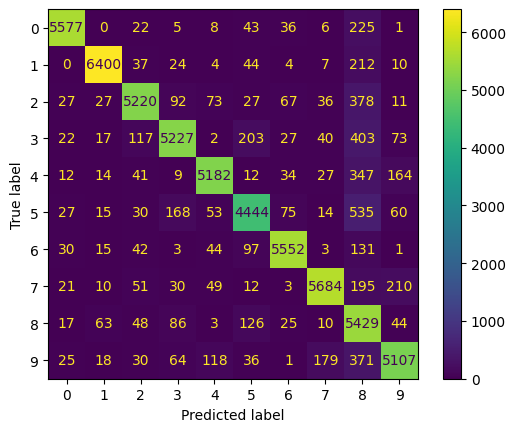

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3, n_jobs=-1)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

- Normalize the confusion matrix by dividing each value by the row's sum
- Show percentage with 0 decimal

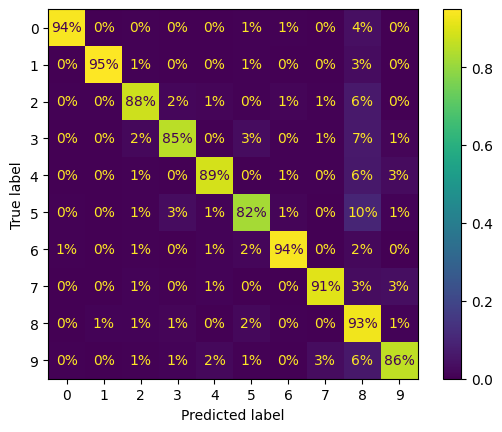

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize="true", values_format=".0%")
plt.show()

- 82% of the images of 5s were classified correctly
- 10% of the images of 5s were classified as 8
- 3% of the images of 5s were classified as 3
- and so on for other classes

- Many digits have been wrongly classified as 8s
- For the errors to stand out, put zero weight on the correct predictions

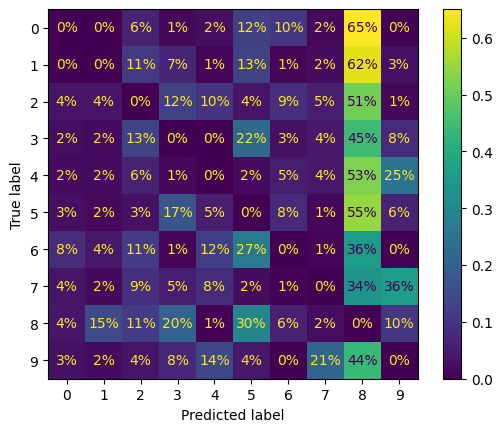

In [ ]:
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, sample_weight=sample_weight, normalize="true", values_format=".0%")
plt.show()

- 36% of the errors the model made on images of 7s were misclassified as 9s
- To normalize the confusion matrix by column rather than row, set `normalize="pred"`
- On the image below, we can see that 56% of misclassified 7s are actually 9s

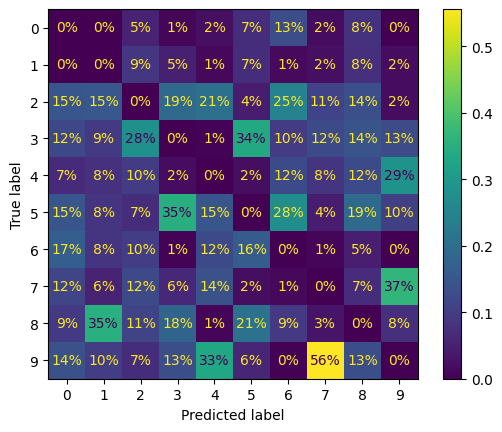

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, sample_weight=sample_weight, normalize="pred", values_format=".0%")
plt.rc('font', size=8)
plt.show()

Analyzing individual errors
- gain insight and see why is it failing
- eg. plot examples of 3s and 5s in confusion matrix style

In [ ]:
def plot_digits(instances, images_per_row=10, index_in_each_row=False, **options):
    """Plots multiple MNIST digits."""
    size = 28
    images_per_row = min(len(instances), images_per_row)
    # This is equivalent to n_rows = ceil(len(instances) / images_per_row):
    n_rows = (len(instances) - 1) // images_per_row + 1

    # Append empty images to fill the end of the grid, if needed:
    padded_instances = np.concatenate([instances, np.zeros((n_rows * images_per_row - len(instances), size * size))], axis=0)

    # Reshape the array so it's a grid of 28×28 images:
    image_grid = padded_instances.reshape(n_rows, images_per_row, size, size)

    # Combine axes 0 and 2 (vertical image axis) and axes 1 and 3 (horizontal image axis):
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size, images_per_row * size)

    # Display the grid:
    plt.imshow(big_image, cmap="binary", **options)
    plt.axis("off")

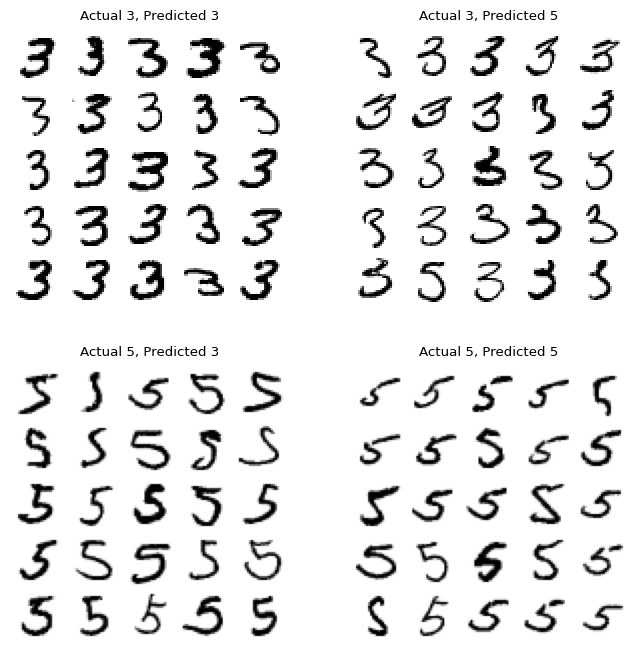

In [ ]:
cl_a, cl_b = 3, 5  # Use integers for class comparison

# Filter original data for actual class 'a' and predicted class 'a'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
# Filter original data for actual class 'a' and predicted class 'b'
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
# Filter original data for actual class 'b' and predicted class 'a'
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
# Filter original data for actual class 'b' and predicted class 'b'
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

# Plot the examples in a 2x2 grid, similar to a confusion matrix
plt.figure(figsize=(8, 8))

plt.subplot(221)
plot_digits(X_aa[:25], images_per_row=5)
plt.title(f"Actual {cl_a}, Predicted {cl_a}") # True Negatives (for this binary case)

plt.subplot(222)
plot_digits(X_ab[:25], images_per_row=5)
plt.title(f"Actual {cl_a}, Predicted {cl_b}") # False Positives (predicted as 5, but are 3)

plt.subplot(223)
plot_digits(X_ba[:25], images_per_row=5)
plt.title(f"Actual {cl_b}, Predicted {cl_a}") # False Negatives (predicted as 3, but are 5)

plt.subplot(224)
plot_digits(X_bb[:25], images_per_row=5)
plt.title(f"Actual {cl_b}, Predicted {cl_b}") # True Positives (for this binary case)

plt.show()

- One way to reduce 3/5 confusion is to preprocess the images
- Ensure they are well centered and not too rotated
- Can be done by augmenting the training set with slightly shifted and rotated variants of the training images
- This approach is called *data augmentation*, will be discussed more in Chapter 14

## Multilabel Classification

- Outputs multiple **binary** tags
- eg. image with multiple animals, classes = {cat, dog, bird}
  - Only a cat → [1, 0, 0]
  - A cat and a dog → [1, 1, 0]
  - All three → [1, 1, 1]

In [ ]:
# Creates a y_multilabel array containing two target labels for each digit image
# First indicates whether or not the digit is large (7, 8, or 9)
# Second indicates whether or not it is odd

import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

knn_clf.predict([some_digit])
# Digit 5 is not large (False) and odd (True)

array([[False,  True]])

Evaluate multilabel classifier
- many approaches, depend on the project
- One approach is measure F1 score for each individual label

In [ ]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3, n_jobs=-1)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048

`average="weighted"` is recommended for imbalanced or multilabel datasets because it weights each class’s F1 score by how many samples it has, giving a fairer reflection of model performance on the actual data distribution.

eg. The dataset has:
- Class A → 900 samples
- Class B → 100 samples

And model performance:
- F1(A) = 0.95
- F1(B) = 0.40

Then:
- macro F1 = (0.95 + 0.40) / 2 = 0.675
- weighted F1 = (0.95×900 + 0.40×100) / 1000 = 0.895

So weighted reflects that the model performs well on the majority of data.

In [ ]:
# The F1 score is same as using macro because the classes are pretty well balanced

f1_score(y_multilabel, y_train_knn_pred, average="weighted")

0.9778357403921755

ClassifierChain
- A multi-label model that arranges binary classifiers into a chain.
- For using classifier that does not natively support multilabel classification like SVC
- Each model makes a prediction in the order specified by the chain using all of the available features provided to the model plus the predictions of models that are earlier in the chain.
- eg. With 3 labels: y₁, y₂, y₃
  - Instead of training 3 independent classifiers, the chain does this:
    - Train classifier for y₁ using only X.
    - Train classifier for y₂ using X and the prediction of y₁ as extra input
    - Train classifier for y₃ using X, y₁, and y₂ as extra inputs.

  - So each label “depends” on earlier ones — a chain of classifiers.
- This helps capture correlation between labels, e.g. “if it’s a cat, it’s probably not a car.”

In [ ]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

chain_clf.predict([some_digit])

array([[0., 1.]])

## Multioutput Classification

- Multilabel → one task, multiple yes/no labels from the same set
- Multioutput → multiple tasks, each with its own label set
- eg. Weather prediction
  - Predict two things for each day:
    - Sky condition → {sunny, cloudy, rainy}
    - Wind level → {low, medium, high}

In [ ]:
np.random.seed(42)

# Creates random integers between 0–99, the same shape as the dataset
noise = np.random.randint(0, 100, (len(X_train), 784))
# Add this noise to each pixel, simulating a “noisy” version of each image
X_train_mod = X_train + noise

noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise

# Clean original digits
y_train_mod = X_train
y_test_mod = X_test

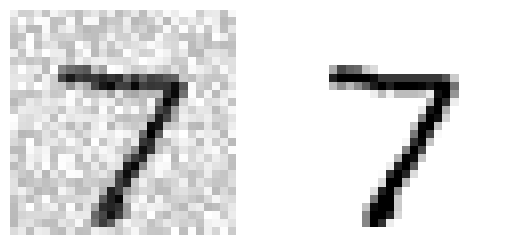

In [ ]:
plt.subplot(121); plot_digit(X_test_mod[0])
plt.subplot(122); plot_digit(y_test_mod[0])
plt.show()

Train KNN on:
- Inputs → noisy images
- Outputs → clean images

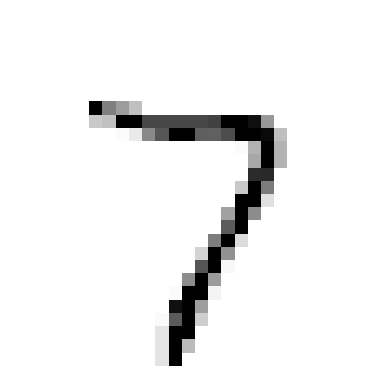

In [ ]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
plt.show()

- The denoising task is called multioutput classification because the model must predict 784 class labels (one per pixel) for each input image
- Each of the 784 outputs (pixels) is treated as a classification problem
- For pixel #i, what discrete intensity (0–255) should it be?

## Exercises

1. Try to build a classifier for the MNIST dataset that achieves over 97% accuracy on the test set. Hint: the KNeighborsClassifier works quite well for this task; you just need to find good hyperparameter values (try a grid search on the weights and n_neighbors hyperparameters).

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = [{'weights': ["uniform", "distance"], 'n_neighbors': [2, 4, 6, 8]}]

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3, verbose=3, n_jobs=-1)

grid_search.fit(X_train[:10_000], y_train[:10_000])

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid=[{'n_neighbors': [2, 4, 6, 8],
                          'weights': ['uniform', 'distance']}],
             verbose=3)

In [ ]:
grid_search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

In [ ]:
grid_search.best_score_

np.float64(0.9703500000000002)

In [ ]:
grid_search.best_estimator_.fit(X_train, y_train)
grid_search.score(X_test, y_test)

0.9714

2. Write a function that can shift an MNIST image in any direction (left, right, up, or down) by one pixel. Then, for each image in the training set, create four shifted copies (one per direction) and add them to the training set. Finally, train your best model on this expanded training set and measure its accuracy on the test set. You should observe that your model performs even better now! This technique of artificially growing the training set is called *data augmentation* or *training set expansion*.

In [ ]:
from scipy.ndimage import shift

def shift_image(image, dx, dy):
    image = image.reshape((28, 28))
    shifted_image = shift(image, [dy, dx], cval=0, mode="constant")

    return shifted_image.reshape([-1])

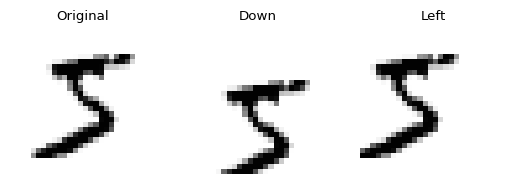

In [ ]:
# Test augment function
images = [some_digit] + [shift_image(some_digit, 0, 5)] + [shift_image(some_digit, -5, 0)]
titles = ["Original", "Down", "Left"]

# Plot 3 subplots
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img.reshape(28, 28), interpolation="nearest", cmap="Greys")
    plt.title(title)
    plt.axis("off")

plt.show()

In [ ]:
X_train_augmented = [image for image in X_train]
y_train_augmented = [label for label in y_train]

for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
    for image, label in zip(X_train, y_train):
        X_train_augmented.append(shift_image(image, dx, dy))
        y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

In [ ]:
# Shuffle the augmented dataset or else they are grouped together
shuffle_idx = np.random.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

In [ ]:
knn_clf = KNeighborsClassifier(**grid_search.best_params_, n_jobs=-1)
knn_clf.fit(X_train_augmented, y_train_augmented)

accuracy = knn_clf.score(X_test, y_test)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9763


3. Tackle the Titanic dataset. A great place to start is on Kaggle. Alternatively, you can download the data from https://homl.info/titanic.tgz and unzip this tarball like you did for the housing data in Chapter 2. This will give you two CSV files: *train.csv* and *test.csv* which you can load using **pandas.read_csv()**. The goal is to train a classifier that can predict the Survived column based on the other columns.

In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_titanic_data():
  tarball_path = Path("datasets/titanic.tgz")
  if not tarball_path.is_file():
    Path("datasets").mkdir(parents=True, exist_ok=True)
    url = "https://github.com/KANGWEII/hands_on_ml/raw/feature-chapter_3/Chapter03/Dataset/titanic.tgz"
    urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as titanic_tarball:
      titanic_tarball.extractall(path="datasets")

  return [pd.read_csv(f"datasets/titanic/{filename}") for filename in ["train.csv", "test.csv"]]

train_data, test_data = load_titanic_data()


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


- Some rows of **Age**, **Cabin**, and **Embarked** attributes are null
- Can ignore **Cabin** attribute as majority are null
- The **Name** and **Ticket** attributes may have some value, but they will be a bit tricky to convert into useful numbers that a model can consume.

The attributes have the following meaning:

- PassengerId: a unique identifier for each passenger
- Survived: that's the target, 0 means the passenger did not survive, while 1 means he/she survived.
- Pclass: passenger class.
- Name, Sex, Age: self-explanatory
- SibSp: how many siblings & spouses of the passenger aboard the Titanic.
- Parch: how many children & parents of the passenger aboard the Titanic.
- Ticket: ticket id
- Fare: price paid (in pounds)
- Cabin: passenger's cabin number
- Embarked: where the passenger embarked the Titanic

In [ ]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Set PassengerId as the index column
train_data = train_data.set_index("PassengerId")
test_data = test_data.set_index("PassengerId")

In [ ]:
train_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699113,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526507,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.416700,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Check number of survivals
train_data["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [ ]:
# Passenger Class
train_data["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [ ]:
# Sex
train_data["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [ ]:
# Embarked
# The Embarked attribute tells us where the passenger embarked: C=Cherbourg, Q=Queenstown, S=Southampton.

train_data["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
# Median age of female passengers
train_data[train_data["Sex"]=="female"]["Age"].median()

27.0

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_attribs = ["Age", "SibSp", "Parch", "Fare"]
cat_attribs = ["Pclass", "Sex", "Embarked"]

num_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),
                         ("scaler", StandardScaler())])

cat_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                         ("cat_encoder", OneHotEncoder(sparse_output=False))])

preprocessing = ColumnTransformer([("num", num_pipeline, num_attribs),
                                   ("cat", cat_pipeline, cat_attribs)])

# fit() learns what transformations to apply
# transform() then applies these transformations to the dataset
x_train = preprocessing.fit_transform(train_data)
y_train = train_data["Survived"]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
forest_clf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_clf, x_train, y_train, cv=10, n_jobs=-1)
print(f"Random Forest Classfier Mean Score: {forest_scores.mean()}")

Random Forest Classfier Mean Score: 0.8137578027465668


In [ ]:
from sklearn.svm import SVC

svm_clf = SVC(gamma="auto")
svm_clf.fit(x_train, y_train)

svm_scores = cross_val_score(svm_clf, x_train, y_train, cv=10, n_jobs=-1)
print(f"Support Vector Machine Mean Score: {svm_scores.mean()}")

Support Vector Machine Mean Score: 0.8249313358302123


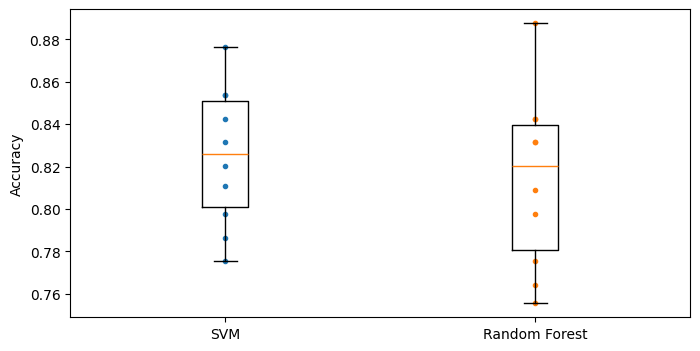

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot([1]*10, svm_scores, ".")
plt.plot([2]*10, forest_scores, ".")
plt.boxplot([svm_scores, forest_scores], tick_labels=("SVM", "Random Forest"))
plt.ylabel("Accuracy")
plt.show()

The random forest classifier got a very high score on one of the 10 folds, but overall it had a lower mean score, as well as a bigger spread, so it looks like the SVM classifier is more likely to generalize well.

From the solution provided by the author to improve this result further, you could:

- Compare many more models and tune hyperparameters using cross validation and grid search,
- Do more feature engineering, for example:
  - Try to convert numerical attributes to categorical attributes: for example, different age groups had very different survival rates (see below), so it may help to create an age bucket category and use it instead of the age. Similarly, it may be useful to have a special category for people traveling alone since only 30% of them survived (see below).
  - Replace SibSp and Parch with their sum.
  - Try to identify parts of names that correlate well with the Survived attribute.
  - Use the Cabin column, for example take its first letter and treat it as a categorical attribute.

In [ ]:
# Creates a new column called "AgeBucket" that groups passenger ages into buckets of 15 years
train_data["AgeBucket"] = train_data["Age"] // 15 * 15

In [ ]:
# Use AgeBucket as a new feature for training
num_attribs = ["Age", "SibSp", "Parch", "Fare"]
cat_attribs = ["Pclass", "Sex", "Embarked", "AgeBucket"]

preprocessing = ColumnTransformer([("num", num_pipeline, num_attribs),
                                   ("cat", cat_pipeline, cat_attribs)])

x_train_agebucket = preprocessing.fit_transform(train_data)
y_train_agebucket = train_data["Survived"]

forest_scores = cross_val_score(forest_clf, x_train_agebucket, y_train_agebucket, cv=10, n_jobs=-1)
forest_clf.fit(x_train_agebucket, y_train_agebucket)
print(f"Random Forest Classfier Mean Score: {forest_scores.mean()}\n")

svm_scores = cross_val_score(svm_clf, x_train_agebucket, y_train_agebucket, cv=10, n_jobs=-1)
svm_clf.fit(x_train_agebucket, y_train_agebucket)
print(f"Support Vector Machine Mean Score: {svm_scores.mean()}")

Random Forest Classfier Mean Score: 0.813732833957553

Support Vector Machine Mean Score: 0.8271785268414481


4. Build a spam classifier (a more challenging exercise):
   - Download examples of spam and ham from Apache SpamAssassin's public datasets (https://homl.info/spamassassin).
   - Unzip the datasets and familiarize yourself with the data format.
   - Split the datasets into a training set and a test set.
   - Write a data preparation pipeline to convert each email into a feature vector. Your preparation pipeline should transform an email into a (sparse) vector that indicates the presence or absence of each possible word. For example, if all emails only ever contain four words, "Hello," "how," "are," "you," then the email "Hello you Hello Hello you" would be converted into a vector [1, 0, 0, 1] (meaning [“Hello" is present, "how" is absent, "are" is absent, "you" is present]), or [3, 0, 0, 2] if you prefer to count the number of occurrences of each word.

      You may want to add hyperparameters to your preparation pipeline to control whether or not to strip off email headers, convert each email to lowercase, remove punctuation, replace all URLs with "URL," replace all numbers with "NUMBER," or even perform _stemming (i.e., trim off word endings; there are Python libraries available to do this)._

   - Finally, try out several classifiers and see if you can build a great spam classifier, with both high recall and high precision.

In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def fetch_data():
  filenames = ["20030228_easy_ham.tar.bz2", "20030228_spam.tar.bz2"]
  extracted_dirs = []

  for filename in filenames:
    tarball_path = Path(f"datasets/{filename}")
    if not tarball_path.is_file():
      Path("datasets").mkdir(parents=True, exist_ok=True)
      url = "https://github.com/KANGWEII/hands_on_ml/raw/feature-chapter_3/Chapter03/Dataset/" + filename
      urllib.request.urlretrieve(url, tarball_path)
      with tarfile.open(tarball_path) as tarball:
        tarball.extractall(path="datasets", filter="data")

    with tarfile.open(tarball_path) as tarball:
      root_name = tarball.getnames()[0].split('/')[0]
      extracted_dir = Path("datasets") / root_name
      extracted_dirs.append(extracted_dir)

  return [file_dir for file_dir in extracted_dirs]

ham_dir, spam_dir = fetch_data()

In [2]:
ham_files = [file for file in sorted(ham_dir.iterdir()) if len(file.name) > 20]
print(f"Number of ham files: {len(ham_files)}")

spam_files = [file for file in sorted(spam_dir.iterdir()) if len(file.name) > 20]
print(f"Number of spam files: {len(spam_files)}")

Number of ham files: 2500
Number of spam files: 500


In [3]:
import email
from email import policy

# Parse a raw email file into an EmailMessage object
def load_email(filepath):
  with open(filepath, "rb") as f:
    return email.parser.BytesParser(policy=policy.default).parse(f)

| Variable        | What it contains     | Type                                         | Example content                                                           |
| --------------- | -------------------- | -------------------------------------------- | ------------------------------------------------------------------------- |
| `ham_files` | Paths to email files | list of `Path` objects                       | `[Path("datasets/easy_ham/00001.7c53336b37003a9286aba55d2945844c"), ...]` |
| `ham_emails`    | Parsed email objects | list of `email.message.EmailMessage` objects | `[<email.message.EmailMessage object at 0x...>, ...]`                     |


- Printing out the first email object in both ham and spam array to see the data structure. The data could be in any of these structures:
  - Simple plain text email
  - Plain and html
  - Has attachments

In [4]:
ham_emails = [load_email(filepath) for filepath in ham_files]
print(ham_emails[0].get_content().strip())

Date:        Wed, 21 Aug 2002 10:54:46 -0500
    From:        Chris Garrigues <cwg-dated-1030377287.06fa6d@DeepEddy.Com>
    Message-ID:  <1029945287.4797.TMDA@deepeddy.vircio.com>


  | I can't reproduce this error.

For me it is very repeatable... (like every time, without fail).

This is the debug log of the pick happening ...

18:19:03 Pick_It {exec pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace} {4852-4852 -sequence mercury}
18:19:03 exec pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace 4852-4852 -sequence mercury
18:19:04 Ftoc_PickMsgs {{1 hit}}
18:19:04 Marking 1 hits
18:19:04 tkerror: syntax error in expression "int ...

Note, if I run the pick command by hand ...

delta$ pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace  4852-4852 -sequence mercury
1 hit

That's where the "1 hit" comes from (obviously).  The version of nmh I'm
using is ...

delta$ pick -version
pick -- nmh-1.0.4 [compiled on fuchsia.cs.mu.OZ.AU at Sun Mar 17 14:55:56 

In [5]:
spam_emails = [load_email(filepath) for filepath in spam_files]
print(spam_emails[0].get_content().strip())

<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 4.0 Transitional//EN">
<HTML><HEAD>
<META content="text/html; charset=windows-1252" http-equiv=Content-Type>
<META content="MSHTML 5.00.2314.1000" name=GENERATOR></HEAD>
<BODY><!-- Inserted by Calypso -->
<TABLE border=0 cellPadding=0 cellSpacing=2 id=_CalyPrintHeader_ rules=none 
style="COLOR: black; DISPLAY: none" width="100%">
  <TBODY>
  <TR>
    <TD colSpan=3>
      <HR color=black noShade SIZE=1>
    </TD></TR></TD></TR>
  <TR>
    <TD colSpan=3>
      <HR color=black noShade SIZE=1>
    </TD></TR></TBODY></TABLE><!-- End Calypso --><!-- Inserted by Calypso --><FONT 
color=#000000 face=VERDANA,ARIAL,HELVETICA size=-2><BR></FONT></TD></TR></TABLE><!-- End Calypso --><FONT color=#ff0000 
face="Copperplate Gothic Bold" size=5 PTSIZE="10">
<CENTER>Save up to 70% on Life Insurance.</CENTER></FONT><FONT color=#ff0000 
face="Copperplate Gothic Bold" size=5 PTSIZE="10">
<CENTER>Why Spend More Than You Have To?
<CENTER><FONT color=#ff0000 face="Copp

Let's look at the various types of structures we have

In [6]:
from collections import Counter

# Recursively describes the MIME structure of one email
def get_email_structure(email):
  if isinstance(email, str):
    return email

  payload = email.get_payload()

  if isinstance(payload, list):
    multipart = ", ".join([get_email_structure(sub_email) for sub_email in payload])
    return f"multipart({multipart})"
  else:
    return email.get_content_type()

# Counts how often each structure appears in the dataset
def structures_counter(emails):
  structures = Counter()

  for email in emails:
    structure = get_email_structure(email)
    structures[structure] += 1

  return structures

In [7]:
structures_counter(ham_emails).most_common()

[('text/plain', 2408),
 ('multipart(text/plain, application/pgp-signature)', 66),
 ('multipart(text/plain, text/html)', 8),
 ('multipart(text/plain, text/plain)', 4),
 ('multipart(text/plain)', 3),
 ('multipart(text/plain, application/octet-stream)', 2),
 ('multipart(text/plain, text/enriched)', 1),
 ('multipart(text/plain, application/ms-tnef, text/plain)', 1),
 ('multipart(multipart(text/plain, text/plain, text/plain), application/pgp-signature)',
  1),
 ('multipart(text/plain, video/mng)', 1),
 ('multipart(text/plain, multipart(text/plain))', 1),
 ('multipart(text/plain, application/x-pkcs7-signature)', 1),
 ('multipart(text/plain, multipart(text/plain, text/plain), text/rfc822-headers)',
  1),
 ('multipart(text/plain, multipart(text/plain, text/plain), multipart(multipart(text/plain, application/x-pkcs7-signature)))',
  1),
 ('multipart(text/plain, application/x-java-applet)', 1)]

In [8]:
structures_counter(spam_emails).most_common()

[('text/plain', 218),
 ('text/html', 183),
 ('multipart(text/plain, text/html)', 45),
 ('multipart(text/html)', 20),
 ('multipart(text/plain)', 19),
 ('multipart(multipart(text/html))', 5),
 ('multipart(text/plain, image/jpeg)', 3),
 ('multipart(text/html, application/octet-stream)', 2),
 ('multipart(text/plain, application/octet-stream)', 1),
 ('multipart(text/html, text/plain)', 1),
 ('multipart(multipart(text/html), application/octet-stream, image/jpeg)', 1),
 ('multipart(multipart(text/plain, text/html), image/gif)', 1),
 ('multipart/alternative', 1)]

Ham Emails
- Dominated by text/plain
- PGP-signed messages: typical in developer communities and secure communications
- Very few emails with HTML or attachments
- Mostly simple, plaintext, human-written, low-gloss emails

Spam Emails
- More HTML emails
- More multipart emails (plain + HTML + attachments)
- Complex, multimedia, HTML-based messages often with attachments or links

In [9]:
# Split dataset into a training set and a test set

# [0] * len(ham_emails)  → makes a list of 0s (one for each ham email)
# [1] * len(spam_emails) → makes a list of 1s (one for each spam email)

import numpy as np
from sklearn.model_selection import train_test_split

X = np.array(ham_emails + spam_emails, dtype=object)
y = np.array([0] * len(ham_emails) + [1] * len(spam_emails))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from bs4 import BeautifulSoup

def html_to_plain_text(html):
  soup = BeautifulSoup(html, "html.parser")

  for tag in soup(["script", "style", "head", "meta", "title", "noscript"]):
    tag.decompose()

  for br in soup.find_all("br"):
    br.replace_with("\n")

  for a in soup.find_all("a"):
    text = a.get_text(" ", strip=True)
    href = a.get("href", "")
    a.replace_with(f"{text} [LINK: {href}]")

  return soup.get_text(separator="\n", strip=True)

In [11]:
# Let's try with the raw html we printed out above

print(html_to_plain_text(spam_emails[0].get_content()))

Save up to 70% on Life Insurance.
Why Spend More Than You Have To?
Life Quote Savings
Ensuring your 
      family's financial security is very important. Life Quote Savings makes 
      buying life insurance simple and affordable. We Provide FREE Access to The 
      Very Best Companies and The Lowest Rates.
Life Quote Savings
is FAST, EASY and 
            SAVES you money! Let us help you get started with the best values in 
            the country on new coverage. You can SAVE hundreds or even thousands 
            of dollars by requesting a FREE quote from Lifequote Savings. Our 
            service will take you less than 5 minutes to complete. Shop and 
            compare. SAVE up to 70% on all types of Life insurance!
Click Here For Your 
            Free Quote! [LINK: http://website.e365.cc/savequote/]
Protecting your family is the best investment you'll ever 
          make!
If you are in receipt of this email 
      in error and/or wish to be removed from our list,
PLEASE CL

In [12]:
# Let's try with the html email used by the author

html_spam_emails = [email for email in X_train[y_train==1] if get_email_structure(email) == "text/html"]

print(html_to_plain_text(html_spam_emails[7].get_content()))

OTC
Newsletter
Discover Tomorrow's Winners
For Immediate Release
Cal-Bay (Stock Symbol: CBYI)
Watch for analyst "Strong Buy Recommendations" and several advisory newsletters picking CBYI.  CBYI has filed to be traded on the OTCBB, share prices historically INCREASE when companies get listed on this larger trading exchange. CBYI is trading around 25 cents and should skyrocket to $2.66 - $3.25 a share in the near future.
Put CBYI on your watch list, acquire a position TODAY.
REASONS TO INVEST IN CBYI
A profitable company and is on track to beat ALL earnings estimates!
One of the FASTEST growing distributors in environmental & safety equipment instruments.
Excellent management team, several EXCLUSIVE contracts.  IMPRESSIVE client list including the U.S. Air Force, Anheuser-Busch, Chevron Refining and Mitsubishi Heavy Industries, GE-Energy & Environmental Research.
RAPIDLY GROWING INDUSTRY
Industry revenues exceed $900 million, estimates indicate that there could be as much as $25 billion 

In [13]:
# Create a function to convert all non-plain emails into text/plain

def email_to_txt(email):
  plain_text = None
  html_text = None

  # Walk through each part of the email (works for multipart and single-part)
  for part in email.walk():
    content_type = part.get_content_type()
    content_disposition = part.get("Content-Disposition", "").lower()

    # Skip attachments
    if "attachment" in content_disposition:
      continue

    # Only process plain or HTML text
    if content_type not in ("text/plain", "text/html"):
      continue

    # Try to get the content safely
    try:
      content = part.get_content()
    except Exception:
      try:
        content = part.get_payload(decode=True)
        content = content.decode(errors="replace") if isinstance(content, bytes) else str(content)
      except Exception:
        content = ""

    # Store content based on type
    if content_type == "text/plain" and not plain_text:
      plain_text = content.strip()
    elif content_type == "text/html" and not html_text:
      html_text = content.strip()

  # Return plain text if available, else convert HTML
  if plain_text:
    return plain_text
  elif html_text:
    return html_to_plain_text(html_text)
  else:
    return ""

In [14]:
# The function should be able to handle all types of email
# Print and test with the emails printed above

print(email_to_txt(ham_emails[0]))

Date:        Wed, 21 Aug 2002 10:54:46 -0500
    From:        Chris Garrigues <cwg-dated-1030377287.06fa6d@DeepEddy.Com>
    Message-ID:  <1029945287.4797.TMDA@deepeddy.vircio.com>


  | I can't reproduce this error.

For me it is very repeatable... (like every time, without fail).

This is the debug log of the pick happening ...

18:19:03 Pick_It {exec pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace} {4852-4852 -sequence mercury}
18:19:03 exec pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace 4852-4852 -sequence mercury
18:19:04 Ftoc_PickMsgs {{1 hit}}
18:19:04 Marking 1 hits
18:19:04 tkerror: syntax error in expression "int ...

Note, if I run the pick command by hand ...

delta$ pick +inbox -list -lbrace -lbrace -subject ftp -rbrace -rbrace  4852-4852 -sequence mercury
1 hit

That's where the "1 hit" comes from (obviously).  The version of nmh I'm
using is ...

delta$ pick -version
pick -- nmh-1.0.4 [compiled on fuchsia.cs.mu.OZ.AU at Sun Mar 17 14:55:56 

In [15]:
print(email_to_txt(html_spam_emails[7]))

OTC
Newsletter
Discover Tomorrow's Winners
For Immediate Release
Cal-Bay (Stock Symbol: CBYI)
Watch for analyst "Strong Buy Recommendations" and several advisory newsletters picking CBYI.  CBYI has filed to be traded on the OTCBB, share prices historically INCREASE when companies get listed on this larger trading exchange. CBYI is trading around 25 cents and should skyrocket to $2.66 - $3.25 a share in the near future.
Put CBYI on your watch list, acquire a position TODAY.
REASONS TO INVEST IN CBYI
A profitable company and is on track to beat ALL earnings estimates!
One of the FASTEST growing distributors in environmental & safety equipment instruments.
Excellent management team, several EXCLUSIVE contracts.  IMPRESSIVE client list including the U.S. Air Force, Anheuser-Busch, Chevron Refining and Mitsubishi Heavy Industries, GE-Energy & Environmental Research.
RAPIDLY GROWING INDUSTRY
Industry revenues exceed $900 million, estimates indicate that there could be as much as $25 billion 

Stemming
- reduces words to their root form
- reduces vocabulary size

urlextract
- It scans through arbitrary text and detects URLs, domains, and links, even when they appear without a protocol like http://
- Can use it to:
  - Remove URLs from text before vectorizing emails or tweets.
  - Count URLs as features (spam messages often contain links).
  - Replace URLs with a placeholder token like "URL"

In [16]:
# Stemming
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer("english")

# urlextract
%pip install -q -U urlextract
import urlextract
url_extractor = urlextract.URLExtract()

In [17]:
import re
from sklearn.base import BaseEstimator, TransformerMixin

class EmailToWordCounterTransformer(BaseEstimator, TransformerMixin):
  def __init__(self, lower_case=True, remove_punctuation=True, replace_urls=True, replace_numbers=True, stemming=True):
    self.lower_case = lower_case
    self.remove_punctuation = remove_punctuation
    self.replace_urls = replace_urls
    self.replace_numbers = replace_numbers
    self.stemming = stemming

  def fit(self, X, y=None):
    return self

  def transform(self, X, y=None):
    X_transformed = []
    for email in X:
      text = email_to_txt(email)

      # Convert to lower case
      if self.lower_case:
        text = text.lower()

      # Remove punctuation
      if self.remove_punctuation:
        text = re.sub(r'\W+', ' ', text, flags=re.M)

      # Replace URLs with "URL"
      if self.replace_urls and url_extractor is not None:
        urls = list(set(url_extractor.find_urls(text)))
        urls.sort(key=lambda url: len(url), reverse=True)
        for url in urls:
          text = text.replace(url, " URL ")

      # Replace numbers with "NUMBER"
      if self.replace_numbers:
        text = re.sub(r'\d+(?:\.\d*)?(?:[eE][+-]?\d+)?', 'NUMBER', text)

      word_counts = Counter(text.split())

      # Stemming
      if self.stemming and stemmer is not None:
        stemmed_word_counts = Counter()
        for word, count in word_counts.items():
          stemmed_word = stemmer.stem(word)
          stemmed_word_counts[stemmed_word] += count

        word_counts = stemmed_word_counts

      X_transformed.append(word_counts)

    return np.array(X_transformed)


In [18]:
# Print the count of email content

X_sample_word_count = EmailToWordCounterTransformer().fit_transform(X_train[:1])

In [19]:
# Raw email for reference to the count printed above

print(X_train[0])

Return-Path: <fork-admin@xent.com>
Delivered-To: yyyy@localhost.spamassassin.taint.org
Received: from localhost (jalapeno [127.0.0.1])
	by jmason.org (Postfix) with ESMTP id DEA8516F03
	for <jm@localhost>; Thu, 19 Sep 2002 13:26:35 +0100 (IST)
Received: from jalapeno [127.0.0.1]
	by localhost with IMAP (fetchmail-5.9.0)
	for jm@localhost (single-drop); Thu, 19 Sep 2002 13:26:35 +0100 (IST)
Received: from xent.com ([64.161.22.236]) by dogma.slashnull.org
    (8.11.6/8.11.6) with ESMTP id g8JCFfC18989 for <jm@jmason.org>;
    Thu, 19 Sep 2002 13:15:42 +0100
Received: from lair.xent.com (localhost [127.0.0.1]) by xent.com (Postfix)
    with ESMTP id B101E294108; Thu, 19 Sep 2002 05:12:05 -0700 (PDT)
Delivered-To: fork@spamassassin.taint.org
Received: from argote.ch (argote.ch [80.65.224.17]) by xent.com (Postfix)
    with ESMTP id 19FF329409E for <fork@xent.com>; Thu, 19 Sep 2002 05:11:32
    -0700 (PDT)
Received: by argote.ch (Postfix, from userid 500) id CA1F9C44D;
    Thu, 19 Sep 2002 

In [23]:
from scipy.sparse import csr_matrix

class WordCounterToVectorTransformer(BaseEstimator, TransformerMixin):
  def __init__(self, vocabulary_size=1000):
    self.vocabulary_size = vocabulary_size

  def fit(self, X, y=None):
    total_count = Counter()
    for word_count in X:
      for word, count in word_count.items():
        total_count[word] += min(count, 10)

    most_common = total_count.most_common()[:self.vocabulary_size]
    self.vocabulary_ = {word: index + 1 for index, (word, count) in enumerate(most_common)}

    return self

  def transform(self, X, y=None):
    rows = []
    cols = []
    data = []

    for row, word_count in enumerate(X):
      for word, count in word_count.items():
        rows.append(row)
        cols.append(self.vocabulary_.get(word, 0))
        data.append(count)

    return csr_matrix((data, (rows, cols)), shape=(len(X), self.vocabulary_size + 1))

In [27]:
vocab_transformer =  WordCounterToVectorTransformer(vocabulary_size=10)
X_sample_word_count_vector = vocab_transformer.fit_transform(X_sample_word_count)

X_sample_word_count_vector.toarray()

array([[0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]])

In [28]:
# Print the index of the vocabulary
# First column shows the number of words that are not part of the vocabulary

vocab_transformer.vocabulary_

{'chuck': 1, 'murcko': 2, 'wrote': 3, 'stuff': 4, 'yawn': 5, 'r': 6}

In [29]:
# Create a pipeline to transform the whole dataset

from sklearn.pipeline import Pipeline

preprocess_pipeline = Pipeline([("email_to_word_count", EmailToWordCounterTransformer()),
                                ("word_count_to_vector", WordCounterToVectorTransformer())])

# X_train_transformed scans all training emails and builds the vocabulary (most common 1000 words) then transform
# X_test_transformed only call transform to reuse the same vocabulary_
X_train_transformed = preprocess_pipeline.fit_transform(X_train)
X_test_transformed = preprocess_pipeline.transform(X_test)

1. Why can't X_test call the fit() function?
   - Calling fit() will rebuild a new vocabulary from scratch on the test emails
   - Breaks the fundamental rule of machine learning: “Never learn anything from your test set.”

In [30]:
# Train and compare with two classification model: LogisticRegression and SVC

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

log_clf = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42)
log_scores = cross_val_score(log_clf, X_train_transformed, y_train, cv=3, verbose=3)
print(f"LogisticRegression Mean Score: {log_scores.mean()}")

svm_clf = SVC(gamma="auto", random_state=42)
svm_scores = cross_val_score(svm_clf, X_train_transformed, y_train, cv=3, verbose=3)
print(f"Support Vector Machine Mean Score: {svm_scores.mean()}")

[CV] END ................................ score: (test=0.983) total time=   0.2s
[CV] END ................................ score: (test=0.986) total time=   0.3s
[CV] END ................................ score: (test=0.993) total time=   0.3s
LogisticRegression Mean Score: 0.9870833333333334


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.7s finished


[CV] END ................................ score: (test=0.935) total time=   1.2s
[CV] END ................................ score: (test=0.953) total time=   1.2s
[CV] END ................................ score: (test=0.954) total time=   1.6s
Support Vector Machine Mean Score: 0.9470833333333334


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    3.9s finished
